# 03 — Customer Segmentation

**Project:** Transaction Intelligence: Customer Segmentation and Behavioral Analytics  
**Dataset:** Berka / PKDD'99 Financial Dataset  
**Course alignment:** **Week 8 — Cluster Analysis and Dimensionality Reduction**

This notebook is the analytical centre of the project. It selects defensible behavioral features, treats skewness and scale, interprets principal components, compares K-means with a Gaussian Mixture Model (GMM), evaluates stability and preprocessing sensitivity, profiles the selected segments, and investigates behavioral outliers.

It does **not** use demographics, loan outcomes, fraud labels, or t-SNE coordinates to construct the segments.

## Notebook objectives

1. Select non-redundant behavioral features and document exclusions.
2. Apply skewness treatment and scaling through a reproducible pipeline.
3. Use PCA to interpret the major behavioral dimensions.
4. Compare K-means and GMM solutions across reasonable cluster counts.
5. Select a stable, interpretable segmentation using multiple criteria.
6. Describe every segment in behavioral and service terms.
7. Identify unusual accounts using four complementary, non-fraud outlier signals.
8. Persist three analytical tables and three fitted model artifacts.

## 1. Analytical contract

The unit of analysis is one bank account. Clusters summarize similarities in the historical Berka snapshot; they are not natural customer “types,” causal explanations, or eligibility categories.

| Decision | Choice | Reason |
|---|---|---|
| Primary clustering family | K-means | Transparent centroid-based baseline and direct distance interpretation |
| Challenger | Gaussian Mixture Model | Probabilistic membership and flexible component covariance |
| Fuzzy C-means | Not implemented | GMM already demonstrates soft membership; adding FCM would expand scope without changing the central comparison |
| PCA | Interpretation and visualization | Linear components expose variance and loadings; full transformed features retain all information for primary clustering |
| t-SNE | Visualization only | Local neighborhoods may be useful visually, but global distances and apparent group sizes are distorted |
| Protected/context variables | Excluded from clustering | Gender, age, district, and loan outcomes must not silently define behavioral segments |

Because this is descriptive unsupervised analysis, the preprocessing pipeline is fitted on the complete historical snapshot. Any future scoring workflow must reuse these fitted transformations and treat distribution shift as a new validation problem.

## 2. Reproducible setup and use of the Gold layer in the project’s medallion data architecture:

Notebook 2 produced one behavioral record per account. This notebook consumes that table without repeating transaction aggregation.

In [1]:
import os

from pathlib import Path
import platform

import duckdb
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing pyproject.toml")


def sql_literal(path: Path) -> str:
    return "'" + str(path).replace("'", "''") + "'"


PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
FEATURES_PATH = PROCESSED_DIR / "customer_behavior_features.parquet"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (11, 5.5), "axes.titleweight": "bold"})

environment = pd.Series(
    {
        "Python": platform.python_version(),
        "DuckDB": duckdb.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "Project root": ".",
    },
    name="value",
)
display(environment.to_frame())

,value
Python,3.14.6
DuckDB,1.5.5
pandas,3.0.5
scikit-learn,1.9.0
Project root,.


In [2]:
assert FEATURES_PATH.is_file(), "Run Notebook 2 before this notebook."

connection = duckdb.connect()
customer_features = connection.execute(
    "SELECT * FROM read_parquet(" + sql_literal(FEATURES_PATH) + ") ORDER BY account_id"
).fetchdf()

input_validation = pd.Series(
    {
        "path": str(FEATURES_PATH.relative_to(PROJECT_ROOT)),
        "rows": len(customer_features),
        "columns": len(customer_features.columns),
        "unique accounts": customer_features["account_id"].nunique(),
        "duplicate account IDs": customer_features["account_id"].duplicated().sum(),
        "total missing values": customer_features.isna().sum().sum(),
    },
    name="value",
)
display(input_validation.to_frame())

assert len(customer_features) == customer_features["account_id"].nunique() == 4_500
assert customer_features["account_id"].duplicated().sum() == 0
assert customer_features.isna().sum().sum() == 0

,value
path,data/processed/customer_behavior_features.parquet
rows,4500
columns,39
unique accounts,4500
duplicate account IDs,0
total missing values,0


## 3. Pre-modelling analysis

### Feature selection

The selected representation balances four behavioral ideas: transaction intensity, cash-flow scale and coverage, balance condition, channel mix, and behavioral/service breadth. Lifetime totals and raw counts are excluded because unequal account tenure would dominate them. Highly redundant features remain available for profiling and sensitivity analysis.

In [3]:
MODEL_FEATURES = [
    "transactions_per_observed_month",
    "average_inflow",
    "inflow_to_outflow_ratio",
    "average_balance",
    "negative_balance_share",
    "cash_deposit_share",
    "cash_withdrawal_share",
    "transaction_diversity",
    "service_diversity",
]

BEHAVIOR_ONLY_FEATURES = [
    feature for feature in MODEL_FEATURES if feature != "service_diversity"
]

EXPANDED_FEATURES = MODEL_FEATURES + [
    "average_outflow",
    "balance_std",
    "incoming_transfer_share",
    "account_tenure_months",
]

PROFILE_CONTINUOUS_FEATURES = [
    "transactions_per_observed_month",
    "average_inflow",
    "average_outflow",
    "inflow_to_outflow_ratio",
    "average_balance",
    "balance_std",
    "negative_balance_share",
    "cash_deposit_share",
    "cash_withdrawal_share",
    "incoming_transfer_share",
    "transaction_diversity",
    "service_diversity",
]

SERVICE_INDICATORS = [
    "has_card",
    "has_loan",
    "has_standing_order",
    "receives_salary_like_deposit",
    "receives_pension",
    "pays_household_expenses",
    "pays_insurance",
    "makes_leasing_payments",
]

feature_decisions = pd.DataFrame(
    [
        {
            "feature or group": "transactions_per_observed_month",
            "decision": "include",
            "reason": "Average monthly transaction activity, adjusted for the account’s observation period.",
        },
        {
            "feature or group": "average_inflow",
            "decision": "include",
            "reason": "Cash-flow scale; average outflow is reserved for profiling because the two are strongly correlated.",
        },
        {
            "feature or group": "inflow_to_outflow_ratio",
            "decision": "include",
            "reason": "Relative funding coverage rather than another absolute value.",
        },
        {
            "feature or group": "average_balance",
            "decision": "include",
            "reason": "Typical account balance level; balance variability is excluded from clustering to reduce redundancy and used afterward to describe the segments.",
        },
        {
            "feature or group": "negative_balance_share",
            "decision": "include",
            "reason": "Frequency of a valid financial state, not a fraud or risk label.",
        },
        {
            "feature or group": "cash_deposit_share, cash_withdrawal_share",
            "decision": "include",
            "reason": "Relative use of cash deposits and cash withdrawals among the account's transactions.",
        },
        {
            "feature or group": "transaction_diversity, service_diversity",
            "decision": "include",
            "reason": "Summarizes transaction and service variety without allowing numerous rare service indicators to disproportionately influence clustering distances.",
        },
        {
            "feature or group": "lifetime counts and totals",
            "decision": "exclude",
            "reason": "accounts were observed for different lengths of time. Older accounts naturally accumulate more transactions and larger totals, even if their monthly behavior is similar.",
        },
        {
            "feature or group": "individual service flags",
            "decision": "profile only",
            "reason": "Used after clustering to describe each segment, without letting uncommon service indicators have too much influence on cluster formation",
        },
        {
            "feature or group": "tenure, demographics, loan outcomes",
            "decision": "context only",
            "reason": "Avoid lifecycle, protected-attribute, and outcome-driven clusters.",
        },
    ]
)
display(feature_decisions)

,feature or group,decision,reason
0,transactions_per_observed_month,include,"Average monthly transaction activity, adjusted..."
1,average_inflow,include,Cash-flow scale; average outflow is reserved f...
2,inflow_to_outflow_ratio,include,Relative funding coverage rather than another ...
3,average_balance,include,Typical account balance level; balance variabi...
4,negative_balance_share,include,"Frequency of a valid financial state, not a fr..."
5,"cash_deposit_share, cash_withdrawal_share",include,Relative use of cash deposits and cash withdra...
6,"transaction_diversity, service_diversity",include,Summarizes transaction and service variety wit...
7,lifetime counts and totals,exclude,accounts were observed for different lengths o...
8,individual service flags,profile only,Used after clustering to describe each segment...
9,"tenure, demographics, loan outcomes",context only,"Avoid lifecycle, protected-attribute, and outc..."


### Skewness treatment and scaling

K-means is distance-based, and GMM is distribution-based. Both are sensitive to scale and extreme skew. The primary pipeline applies a fitted Yeo-Johnson transformation followed by standardization:

1. **Yeo-Johnson:** reduces skewness while supporting zeros. This is an additional preprocessing technique, used to reduce feature skewness while supporting zero-valued observations.
2. **StandardScaler:** gives every transformed feature mean approximately zero and variance one.

All accounts and valid extreme values are retained. Later, clustering with and without the Yeo-Johnson transformation is compared to determine how much this preprocessing choice affects the results.

In [4]:
preprocessing_pipeline = Pipeline(
    steps=[
        ("power", PowerTransformer(method="yeo-johnson", standardize=False)),
        ("scale", StandardScaler()),
    ]
)

model_input = customer_features[MODEL_FEATURES].copy()
transformed_matrix = preprocessing_pipeline.fit_transform(model_input)
transformed_features = pd.DataFrame(
    transformed_matrix,
    columns=MODEL_FEATURES,
    index=customer_features.index,
)

skewness_comparison = pd.DataFrame(
    {
        "raw_skewness": model_input.skew(),
        "transformed_skewness": transformed_features.skew(),
    }
).assign(
    absolute_skewness_reduction=lambda frame: (
        frame["raw_skewness"].abs() - frame["transformed_skewness"].abs()
    )
)
display(skewness_comparison.sort_values("raw_skewness", key=lambda series: series.abs(), ascending=False))

scaling_check = pd.DataFrame(
    {
        "transformed_mean": transformed_features.mean(),
        "transformed_std": transformed_features.std(ddof=0),
    }
)
display(scaling_check)

assert np.allclose(transformed_features.mean(), 0, atol=1e-8)
assert np.allclose(transformed_features.std(ddof=0), 1, atol=1e-8)

,raw_skewness,transformed_skewness,absolute_skewness_reduction
inflow_to_outflow_ratio,29.427746,0.278535,29.149211
negative_balance_share,10.944827,3.850112,7.094715
average_inflow,0.857383,-0.036530,0.820853
average_balance,0.457376,-0.035112,0.422264
service_diversity,-0.442770,-0.074334,0.368436
cash_deposit_share,0.392768,0.013079,0.379688
cash_withdrawal_share,0.256302,0.001896,0.254406
transactions_per_observed_month,-0.149500,0.155774,-0.006273
transaction_diversity,-0.074430,0.056925,0.017505


,transformed_mean,transformed_std
transactions_per_observed_month,-9.347584e-16,1.0
average_inflow,-6.568573e-16,1.0
inflow_to_outflow_ratio,6.694892e-14,1.0
average_balance,-3.915880e-16,1.0
negative_balance_share,0.000000e+00,1.0
cash_deposit_share,1.010550e-16,1.0
cash_withdrawal_share,1.263187e-16,1.0
transaction_diversity,-7.073848e-16,1.0
service_diversity,6.947529e-17,1.0


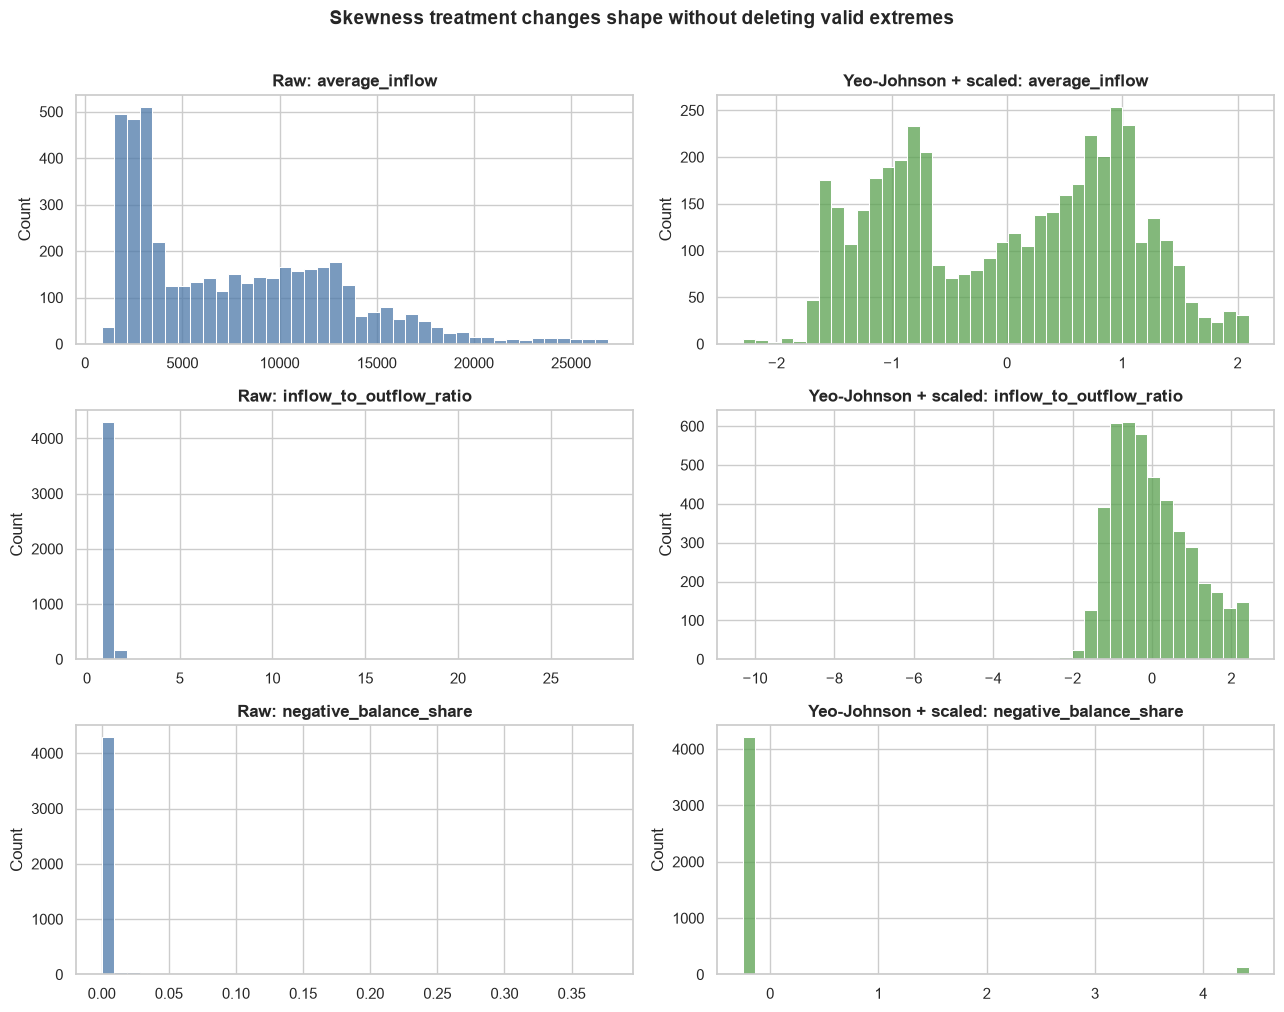

In [5]:
distribution_features = ["average_inflow", "inflow_to_outflow_ratio", "negative_balance_share"]
fig, axes = plt.subplots(len(distribution_features), 2, figsize=(13, 10))
for row, feature in enumerate(distribution_features):
    sns.histplot(model_input[feature], bins=40, color="#4C78A8", ax=axes[row, 0])
    axes[row, 0].set(title=f"Raw: {feature}", xlabel="")
    sns.histplot(transformed_features[feature], bins=40, color="#59A14F", ax=axes[row, 1])
    axes[row, 1].set(title=f"Yeo-Johnson + scaled: {feature}", xlabel="")
fig.suptitle("Skewness treatment changes shape without deleting valid extremes", y=1.01, fontsize=14, weight="bold")
fig.tight_layout()
plt.show()

### Correlation and redundancy

Spearman correlation is used because many behaviors are non-normal and monotonic rather than linear. Correlation is a redundancy diagnostic here, not evidence of causation.

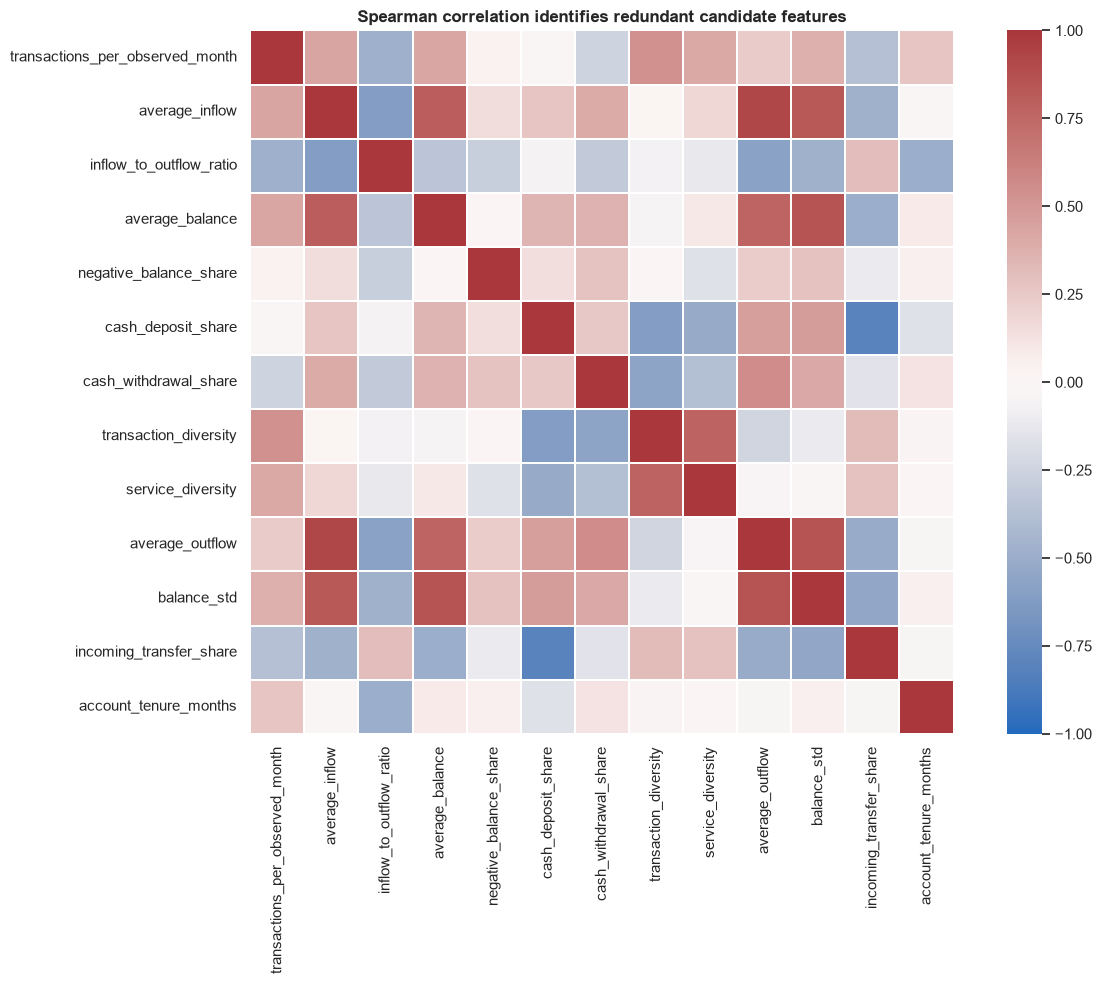

,feature_a,feature_b,spearman_rho,abs_rho
22,average_inflow,average_outflow,0.928279,0.928279
49,average_balance,balance_std,0.858687,0.858687
127,average_outflow,balance_std,0.858659,0.858659
23,average_inflow,balance_std,0.831461,0.831461
16,average_inflow,average_balance,0.807475,0.807475
76,cash_deposit_share,incoming_transfer_share,-0.807439,0.807439
99,transaction_diversity,service_diversity,0.776768,0.776768
48,average_balance,average_outflow,0.769096,0.769096
72,cash_deposit_share,transaction_diversity,-0.610223,0.610223
15,average_inflow,inflow_to_outflow_ratio,-0.609824,0.609824


In [6]:
correlation_candidates = list(dict.fromkeys(EXPANDED_FEATURES))
spearman_correlation = customer_features[correlation_candidates].corr(method="spearman")

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    spearman_correlation,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.35,
    ax=ax,
)
ax.set_title("Spearman correlation identifies redundant candidate features")
fig.tight_layout()
plt.show()

upper_triangle = spearman_correlation.where(
    np.triu(np.ones(spearman_correlation.shape, dtype=bool), k=1)
)
strongest_correlations = (
    upper_triangle.stack()
    .rename("spearman_rho")
    .reset_index()
    .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
    .assign(abs_rho=lambda frame: frame["spearman_rho"].abs())
    .sort_values("abs_rho", ascending=False)
    .head(12)
)
display(strongest_correlations)

## 4. Principal Component Analysis

PCA is fitted to the transformed nine-feature matrix. It is used to quantify variance, interpret combinations of behavior through loadings, and visualize the selected segments. The primary clustering model remains in the full transformed feature space.

,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.331428,0.331428
1,2,0.302605,0.634032
2,3,0.132606,0.766638
3,4,0.095489,0.862127
4,5,0.063871,0.925998
5,6,0.034853,0.960850
6,7,0.018059,0.978909
7,8,0.012016,0.990925
8,9,0.009075,1.000000


Components required for at least 85% explained variance: 4


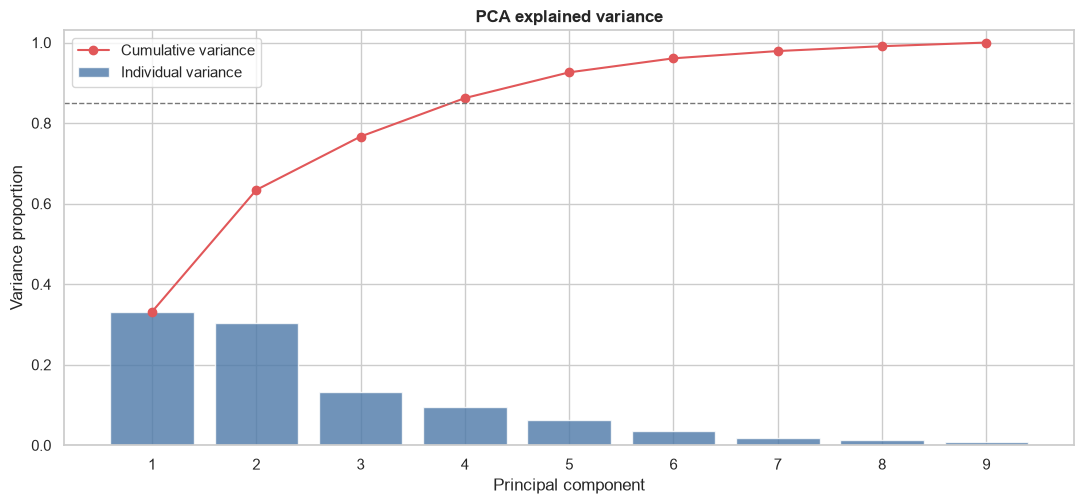

In [7]:
pca = PCA()
pca_scores = pca.fit_transform(transformed_matrix)

explained_variance = pd.DataFrame(
    {
        "component": np.arange(1, len(MODEL_FEATURES) + 1),
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
    }
)
components_for_85_pct = int(
    explained_variance.loc[
        explained_variance["cumulative_explained_variance"] >= 0.85,
        "component",
    ].iloc[0]
)
display(explained_variance)
print(f"Components required for at least 85% explained variance: {components_for_85_pct}")

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.bar(
    explained_variance["component"],
    explained_variance["explained_variance_ratio"],
    color="#4C78A8",
    alpha=0.8,
    label="Individual variance",
)
ax.plot(
    explained_variance["component"],
    explained_variance["cumulative_explained_variance"],
    marker="o",
    color="#E15759",
    label="Cumulative variance",
)
ax.axhline(0.85, color="#777777", linestyle="--", linewidth=1)
ax.set(
    title="PCA explained variance",
    xlabel="Principal component",
    ylabel="Variance proportion",
    xticks=explained_variance["component"],
    ylim=(0, 1.03),
)
ax.legend()
fig.tight_layout()
plt.show()

,PC1,PC2,PC3,PC4
transactions_per_observed_month,0.491,0.079,-0.076,0.335
average_inflow,0.288,0.471,-0.122,-0.146
inflow_to_outflow_ratio,-0.277,-0.347,-0.321,-0.007
average_balance,0.218,0.441,-0.386,-0.112
negative_balance_share,-0.002,0.201,0.708,0.429
cash_deposit_share,-0.219,0.355,-0.352,0.597
cash_withdrawal_share,-0.158,0.434,0.288,-0.522
transaction_diversity,0.496,-0.246,0.124,0.079
service_diversity,0.483,-0.203,-0.051,-0.185


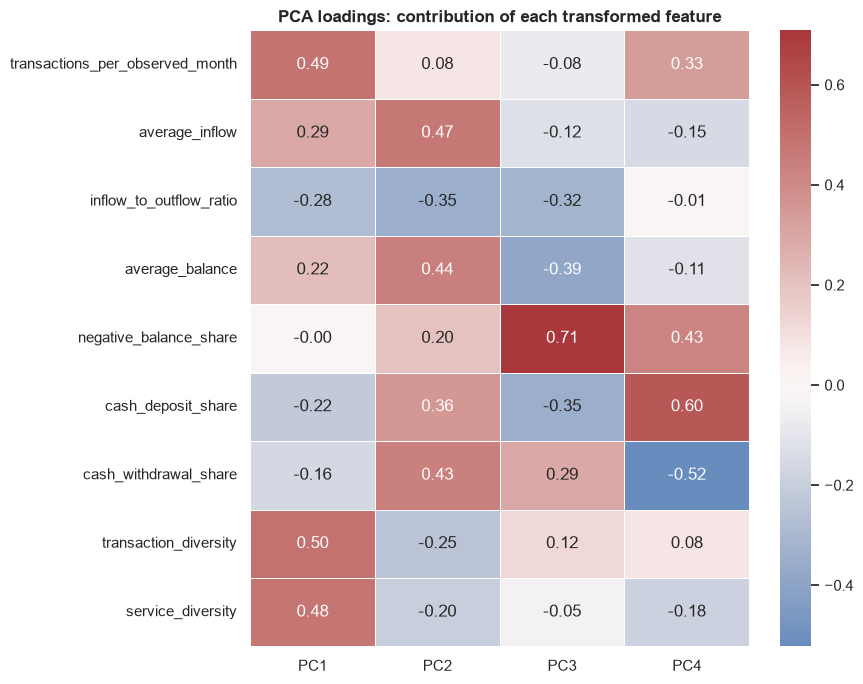

,component,explained_variance,strongest_loadings
0,PC1,0.331428,transaction_diversity (+0.50); transactions_pe...
1,PC2,0.302605,average_inflow (+0.47); average_balance (+0.44...
2,PC3,0.132606,negative_balance_share (+0.71); average_balanc...
3,PC4,0.095489,cash_deposit_share (+0.60); cash_withdrawal_sh...


In [8]:
PCA_COMPONENTS_TO_INTERPRET = 4
pca_loadings = pd.DataFrame(
    pca.components_[:PCA_COMPONENTS_TO_INTERPRET].T,
    index=MODEL_FEATURES,
    columns=[f"PC{number}" for number in range(1, PCA_COMPONENTS_TO_INTERPRET + 1)],
)
display(pca_loadings.round(3))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    pca_loadings,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("PCA loadings: contribution of each transformed feature")
fig.tight_layout()
plt.show()

loading_summary_rows = []
for component in pca_loadings.columns:
    strongest = pca_loadings[component].abs().nlargest(3).index
    loading_summary_rows.append(
        {
            "component": component,
            "explained_variance": explained_variance.loc[
                explained_variance["component"] == int(component[2:]),
                "explained_variance_ratio",
            ].iloc[0],
            "strongest_loadings": "; ".join(
                f"{feature} ({pca_loadings.loc[feature, component]:+.2f})" for feature in strongest
            ),
        }
    )
display(pd.DataFrame(loading_summary_rows))

The first two components explain about 63% of transformed variance. PC1 primarily represents engagement breadth and activity intensity; PC2 emphasizes cash-flow and balance scale. Four components exceed 85%, so a four-component clustering sensitivity check is included later. Loading signs are arbitrary; relative magnitude and co-direction are what matter.

## 5. K-means baseline and value of K

Candidate values from 2 through 8 are compared. Inertia supports the elbow method; silhouette rewards cohesion and separation; Davies-Bouldin rewards low within-to-between-cluster similarity. No single metric is treated as sufficient.

,k,inertia,silhouette,davies_bouldin,smallest_cluster,largest_cluster,smallest_cluster_share,inertia_reduction_from_previous_k
0,2,31258.626167,0.234722,1.683423,2196,2304,0.488000,NaN
1,3,24462.728267,0.261868,1.372727,1343,1642,0.298444,0.217409
2,4,20231.252337,0.291206,1.184290,262,1457,0.058222,0.172976
3,5,17075.236757,0.304458,1.179629,251,1519,0.055778,0.155997
4,6,15580.846230,0.264367,1.246993,250,1177,0.055556,0.087518
5,7,14313.337136,0.270639,1.203542,149,1179,0.033111,0.081350
6,8,13463.442263,0.261172,1.281153,144,1135,0.032000,0.059378


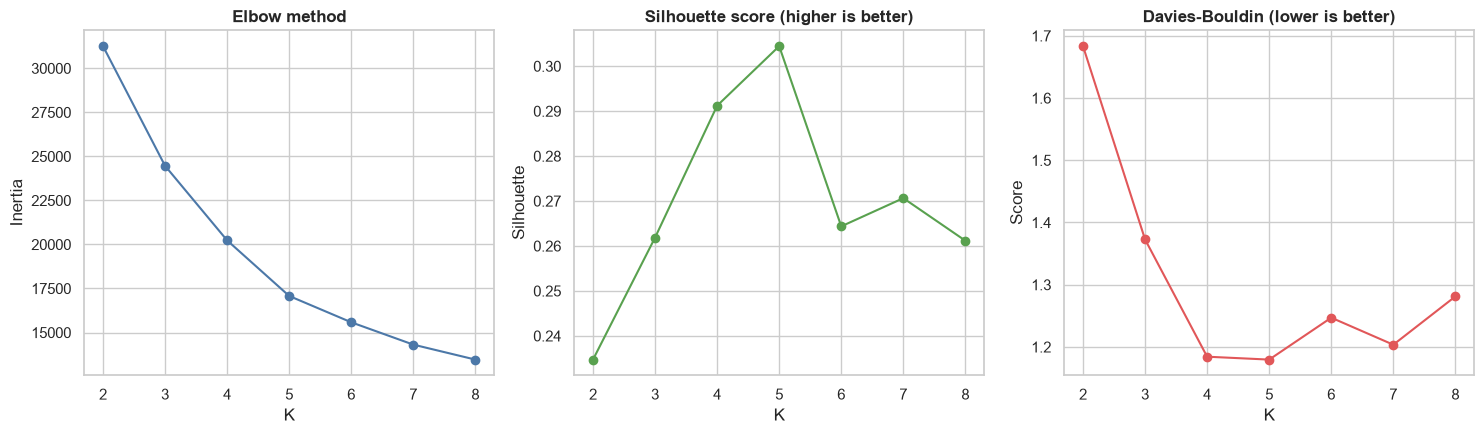

In [9]:
K_VALUES = range(2, 9)
RANDOM_STATE = 42

kmeans_models = {}
kmeans_rows = []
for number_of_clusters in K_VALUES:
    model = KMeans(
        n_clusters=number_of_clusters,
        n_init=50,
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(transformed_matrix)
    cluster_counts = np.bincount(labels, minlength=number_of_clusters)
    kmeans_models[number_of_clusters] = model
    kmeans_rows.append(
        {
            "k": number_of_clusters,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(transformed_matrix, labels),
            "davies_bouldin": davies_bouldin_score(transformed_matrix, labels),
            "smallest_cluster": cluster_counts.min(),
            "largest_cluster": cluster_counts.max(),
            "smallest_cluster_share": cluster_counts.min() / len(labels),
        }
    )

kmeans_evaluation = pd.DataFrame(kmeans_rows)
kmeans_evaluation["inertia_reduction_from_previous_k"] = (
    -kmeans_evaluation["inertia"].pct_change()
)
display(kmeans_evaluation)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(kmeans_evaluation["k"], kmeans_evaluation["inertia"], marker="o", color="#4C78A8")
axes[0].set(title="Elbow method", xlabel="K", ylabel="Inertia")
axes[1].plot(kmeans_evaluation["k"], kmeans_evaluation["silhouette"], marker="o", color="#59A14F")
axes[1].set(title="Silhouette score (higher is better)", xlabel="K", ylabel="Silhouette")
axes[2].plot(kmeans_evaluation["k"], kmeans_evaluation["davies_bouldin"], marker="o", color="#E15759")
axes[2].set(title="Davies-Bouldin (lower is better)", xlabel="K", ylabel="Score")
for axis in axes:
    axis.set_xticks(list(K_VALUES))
fig.tight_layout()
plt.show()

### Selected K: 5

Five clusters provide the strongest combined case:

- the highest silhouette score in the tested K-means range;
- a near-minimum Davies-Bouldin score;
- a clear reduction in marginal inertia improvement after K=5;
- no negligible cluster (the smallest contains about 5.6% of accounts);
- distinct, explainable transaction, balance, and service profiles;
- excellent stability across initialization seeds, tested below.

The selection is therefore not based only on the visual elbow or on maximizing a single metric.

In [10]:
SELECTED_K = 5
best_silhouette_k = int(
    kmeans_evaluation.loc[kmeans_evaluation["silhouette"].idxmax(), "k"]
)
assert SELECTED_K == best_silhouette_k

kmeans_model = kmeans_models[SELECTED_K]
kmeans_labels = kmeans_model.labels_

## 6. Gaussian Mixture Model challenger

GMM provides soft membership probabilities and allows elliptical components through full covariance matrices. AIC and BIC are reported alongside hard-label silhouette and Davies-Bouldin scores. Lower AIC/BIC is preferable, but component likelihood alone does not guarantee useful customer segments.

,k,aic,bic,silhouette,davies_bouldin,smallest_component,largest_component
0,2,26125.407546,26824.297307,0.375246,1.654763,346,4154
1,3,14579.446580,15630.987139,0.214048,1.493994,332,3174
2,4,11203.889316,12608.080671,0.229956,1.358769,288,2113
3,5,-5845.363035,-4088.520882,0.156777,2.138954,288,1441
4,6,-8639.972137,-6530.479187,0.200257,1.699027,288,1065
5,7,-2142.499690,319.644058,0.219499,1.592882,100,1170
6,8,-17888.616869,-15073.822324,0.132512,2.244698,250,924


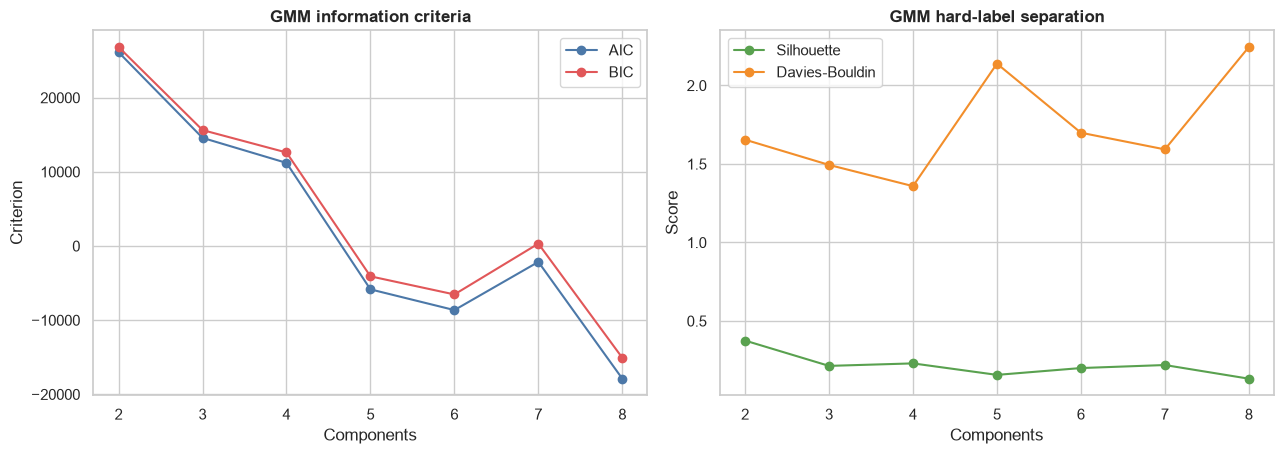

In [11]:
gmm_models = {}
gmm_rows = []
for number_of_components in K_VALUES:
    model = GaussianMixture(
        n_components=number_of_components,
        covariance_type="full",
        n_init=5,
        reg_covar=1e-6,
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(transformed_matrix)
    component_counts = np.bincount(labels, minlength=number_of_components)
    gmm_models[number_of_components] = model
    gmm_rows.append(
        {
            "k": number_of_components,
            "aic": model.aic(transformed_matrix),
            "bic": model.bic(transformed_matrix),
            "silhouette": silhouette_score(transformed_matrix, labels),
            "davies_bouldin": davies_bouldin_score(transformed_matrix, labels),
            "smallest_component": component_counts.min(),
            "largest_component": component_counts.max(),
        }
    )

gmm_evaluation = pd.DataFrame(gmm_rows)
display(gmm_evaluation)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
axes[0].plot(gmm_evaluation["k"], gmm_evaluation["aic"], marker="o", label="AIC", color="#4C78A8")
axes[0].plot(gmm_evaluation["k"], gmm_evaluation["bic"], marker="o", label="BIC", color="#E15759")
axes[0].set(title="GMM information criteria", xlabel="Components", ylabel="Criterion")
axes[0].legend()
axes[1].plot(gmm_evaluation["k"], gmm_evaluation["silhouette"], marker="o", label="Silhouette", color="#59A14F")
axes[1].plot(gmm_evaluation["k"], gmm_evaluation["davies_bouldin"], marker="o", label="Davies-Bouldin", color="#F28E2B")
axes[1].set(title="GMM hard-label separation", xlabel="Components", ylabel="Score")
axes[1].legend()
for axis in axes:
    axis.set_xticks(list(K_VALUES))
fig.tight_layout()
plt.show()

gmm_model = gmm_models[SELECTED_K]
gmm_labels = gmm_model.predict(transformed_matrix)
gmm_membership_probabilities = gmm_model.predict_proba(transformed_matrix)

In [12]:
algorithm_comparison = pd.DataFrame(
    [
        {
            "algorithm": "K-means",
            "k": SELECTED_K,
            "silhouette": silhouette_score(transformed_matrix, kmeans_labels),
            "davies_bouldin": davies_bouldin_score(transformed_matrix, kmeans_labels),
            "smallest_group": np.bincount(kmeans_labels).min(),
            "largest_group": np.bincount(kmeans_labels).max(),
            "soft_membership": False,
        },
        {
            "algorithm": "GMM (matched K)",
            "k": SELECTED_K,
            "silhouette": silhouette_score(transformed_matrix, gmm_labels),
            "davies_bouldin": davies_bouldin_score(transformed_matrix, gmm_labels),
            "smallest_group": np.bincount(gmm_labels, minlength=SELECTED_K).min(),
            "largest_group": np.bincount(gmm_labels, minlength=SELECTED_K).max(),
            "soft_membership": True,
        },
    ]
)
display(algorithm_comparison)

gmm_bic_boundary_k = int(gmm_evaluation.loc[gmm_evaluation["bic"].idxmin(), "k"])
print(
    f"The lowest tested GMM BIC occurs at K={gmm_bic_boundary_k}, "
    "the search boundary rather than a compact interior optimum."
)

,algorithm,k,silhouette,davies_bouldin,smallest_group,largest_group,soft_membership
0,K-means,5,0.304458,1.179629,251,1519,False
1,GMM (matched K),5,0.156777,2.138954,288,1441,True


The lowest tested GMM BIC occurs at K=8, the search boundary rather than a compact interior optimum.


K-means is retained as the primary model. At matched K=5 it provides materially better silhouette and Davies-Bouldin separation, produces operationally readable centroids, and supports direct centroid-distance outlier analysis. The GMM search reaches its lowest BIC at the upper boundary rather than a compact interior optimum, and the zero-inflated/discrete behaviors also strain a Gaussian assumption. GMM remains valuable as a challenger and as a source of membership uncertainty.

## 7. Stability and sensitivity

Adjusted Rand Index (ARI) compares assignments without depending on numeric cluster labels. ARI near 1 means two solutions assign nearly all account pairs consistently.

In [13]:
STABILITY_SEEDS = [7, 21, 42, 84, 168]
stability_rows = []
for seed in STABILITY_SEEDS:
    seed_kmeans_labels = KMeans(
        n_clusters=SELECTED_K,
        n_init=20,
        random_state=seed,
    ).fit_predict(transformed_matrix)
    stability_rows.append(
        {
            "algorithm": "K-means",
            "seed": seed,
            "ARI_vs_reference": adjusted_rand_score(kmeans_labels, seed_kmeans_labels),
        }
    )

    seed_gmm_labels = GaussianMixture(
        n_components=SELECTED_K,
        covariance_type="full",
        n_init=5,
        reg_covar=1e-6,
        random_state=seed,
    ).fit_predict(transformed_matrix)
    stability_rows.append(
        {
            "algorithm": "GMM",
            "seed": seed,
            "ARI_vs_reference": adjusted_rand_score(gmm_labels, seed_gmm_labels),
        }
    )

stability_results = pd.DataFrame(stability_rows)
display(stability_results)
display(
    stability_results.groupby("algorithm")["ARI_vs_reference"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

,algorithm,seed,ARI_vs_reference
0,K-means,7,0.997649
1,GMM,7,0.998837
2,K-means,21,0.995301
3,GMM,21,0.998837
4,K-means,42,0.996639
5,GMM,42,1.000000
6,K-means,84,0.997649
7,GMM,84,1.000000
8,K-means,168,0.995040
9,GMM,168,1.000000


,algorithm,mean,min,max
0,GMM,0.999535,0.998837,1.000000
1,K-means,0.996456,0.995040,0.997649


In [14]:
def transformed_variant(
    feature_names: list[str],
    use_power_transform: bool,
) -> np.ndarray:
    steps = []
    if use_power_transform:
        steps.append(("power", PowerTransformer(method="yeo-johnson", standardize=False)))
    steps.append(("scale", StandardScaler()))
    pipeline = Pipeline(steps=steps)
    return pipeline.fit_transform(customer_features[feature_names])


sensitivity_scenarios = {
    "Primary: selected + power + scale": {
        "matrix": transformed_matrix,
        "feature_count": len(MODEL_FEATURES),
    },
    "No skewness treatment": {
        "matrix": transformed_variant(MODEL_FEATURES, use_power_transform=False),
        "feature_count": len(MODEL_FEATURES),
    },
    "Behavior only (no service diversity)": {
        "matrix": transformed_variant(BEHAVIOR_ONLY_FEATURES, use_power_transform=True),
        "feature_count": len(BEHAVIOR_ONLY_FEATURES),
    },
    "Expanded redundant/context features": {
        "matrix": transformed_variant(EXPANDED_FEATURES, use_power_transform=True),
        "feature_count": len(EXPANDED_FEATURES),
    },
    "First four PCs (86% variance)": {
        "matrix": pca_scores[:, :components_for_85_pct],
        "feature_count": components_for_85_pct,
    },
}

sensitivity_rows = []
for scenario_name, scenario in sensitivity_scenarios.items():
    scenario_matrix = scenario["matrix"]
    scenario_labels = KMeans(
        n_clusters=SELECTED_K,
        n_init=50,
        random_state=RANDOM_STATE,
    ).fit_predict(scenario_matrix)
    counts = np.bincount(scenario_labels, minlength=SELECTED_K)
    sensitivity_rows.append(
        {
            "scenario": scenario_name,
            "dimensions": scenario["feature_count"],
            "ARI_vs_primary": adjusted_rand_score(kmeans_labels, scenario_labels),
            "silhouette": silhouette_score(scenario_matrix, scenario_labels),
            "davies_bouldin": davies_bouldin_score(scenario_matrix, scenario_labels),
            "smallest_cluster": counts.min(),
            "smallest_cluster_share": counts.min() / len(scenario_labels),
        }
    )

sensitivity_results = pd.DataFrame(sensitivity_rows)
display(sensitivity_results)

,scenario,dimensions,ARI_vs_primary,silhouette,davies_bouldin,smallest_cluster,smallest_cluster_share
0,Primary: selected + power + scale,9,1.000000,0.304458,1.179629,251,0.055778
1,No skewness treatment,9,0.468876,0.284467,0.933960,2,0.000444
2,Behavior only (no service diversity),8,0.734272,0.309326,1.152619,258,0.057333
3,Expanded redundant/context features,13,0.748029,0.273250,1.361705,250,0.055556
4,First four PCs (86% variance),4,0.969642,0.371349,0.959891,247,0.054889


The sensitivity analysis supports three conclusions:

- removing skewness treatment creates a nearly empty cluster, showing that untransformed extremes can dominate K-means;
- removing service diversity or adding redundant/context variables changes some assignments but preserves substantial structure;
- clustering the first four PCs produces nearly the same solution, supporting the selected structure while the full feature space retains the remaining variance.

Sensitivity is evidence about robustness, not proof that five “true” groups exist.

## 8. Selected segment visualization

The numeric K-means labels are arbitrary. Stable descriptive names are attached only after reviewing original-scale profiles.

,segment_id,segment_name,population_size,population_share
1,0,Pension-associated households,1305,0.290000
0,1,Established household users,1519,0.337556
2,2,High-activity multi-service users,838,0.186222
4,3,High-volatility cash users,251,0.055778
3,4,Low-service cash users,587,0.130444


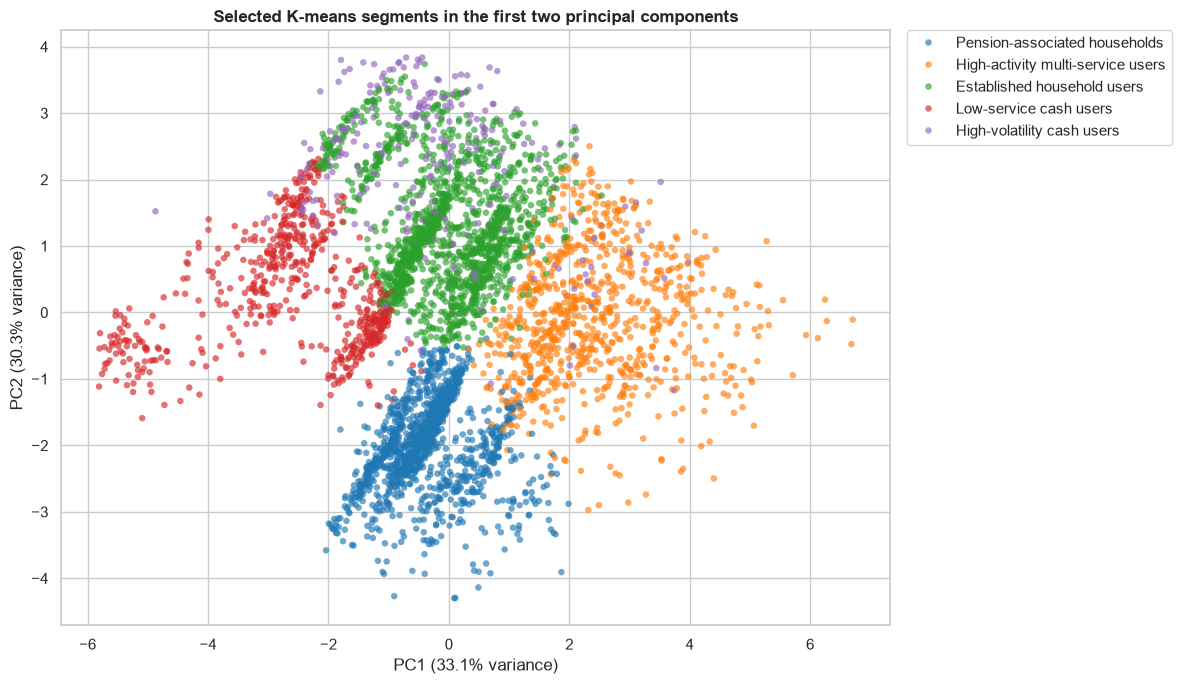

In [15]:
segment_naming_data = customer_features[
    [
        "transactions_per_observed_month",
        "balance_std",
        "service_diversity",
        "receives_pension",
    ]
].copy()
segment_naming_data["model_cluster_id"] = kmeans_labels
segment_naming_profile = segment_naming_data.groupby("model_cluster_id").agg(
    median_transaction_intensity=("transactions_per_observed_month", "median"),
    median_balance_volatility=("balance_std", "median"),
    median_service_diversity=("service_diversity", "median"),
    pension_rate=("receives_pension", "mean"),
)

unassigned_cluster_ids = set(segment_naming_profile.index)
pension_cluster_id = int(segment_naming_profile["pension_rate"].idxmax())
unassigned_cluster_ids.remove(pension_cluster_id)

volatility_cluster_id = int(
    segment_naming_profile.loc[list(unassigned_cluster_ids), "median_balance_volatility"].idxmax()
)
unassigned_cluster_ids.remove(volatility_cluster_id)

high_activity_cluster_id = int(
    segment_naming_profile.loc[list(unassigned_cluster_ids), "median_transaction_intensity"].idxmax()
)
unassigned_cluster_ids.remove(high_activity_cluster_id)

low_service_cluster_id = int(
    segment_naming_profile.loc[list(unassigned_cluster_ids), "median_service_diversity"].idxmin()
)
unassigned_cluster_ids.remove(low_service_cluster_id)
established_cluster_id = int(unassigned_cluster_ids.pop())

SEGMENT_NAME_MAP = {
    pension_cluster_id: "Pension-associated households",
    established_cluster_id: "Established household users",
    high_activity_cluster_id: "High-activity multi-service users",
    volatility_cluster_id: "High-volatility cash users",
    low_service_cluster_id: "Low-service cash users",
}
assert len(SEGMENT_NAME_MAP) == SELECTED_K

segment_names = pd.Series(kmeans_labels).map(SEGMENT_NAME_MAP).to_numpy()
cluster_sizes = (
    pd.DataFrame({"segment_id": kmeans_labels, "segment_name": segment_names})
    .value_counts(["segment_id", "segment_name"])
    .rename("population_size")
    .reset_index()
    .assign(population_share=lambda frame: frame["population_size"] / len(customer_features))
    .sort_values("segment_id")
)
display(cluster_sizes)

pca_visualization = pd.DataFrame(
    {
        "PC1": pca_scores[:, 0],
        "PC2": pca_scores[:, 1],
        "segment_name": segment_names,
    }
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=pca_visualization,
    x="PC1",
    y="PC2",
    hue="segment_name",
    palette="tab10",
    s=22,
    alpha=0.65,
    linewidth=0,
    ax=ax,
)
ax.set(
    title="Selected K-means segments in the first two principal components",
    xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
    ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)",
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
fig.tight_layout()
plt.show()

### Optional t-SNE view

t-SNE is fitted only to create a second visual perspective on local neighborhoods. It is not used for K selection, clustering, stability, segment sizes, or outlier scores. Distances between separated groups and the visual area occupied by each color are not quantitatively meaningful.

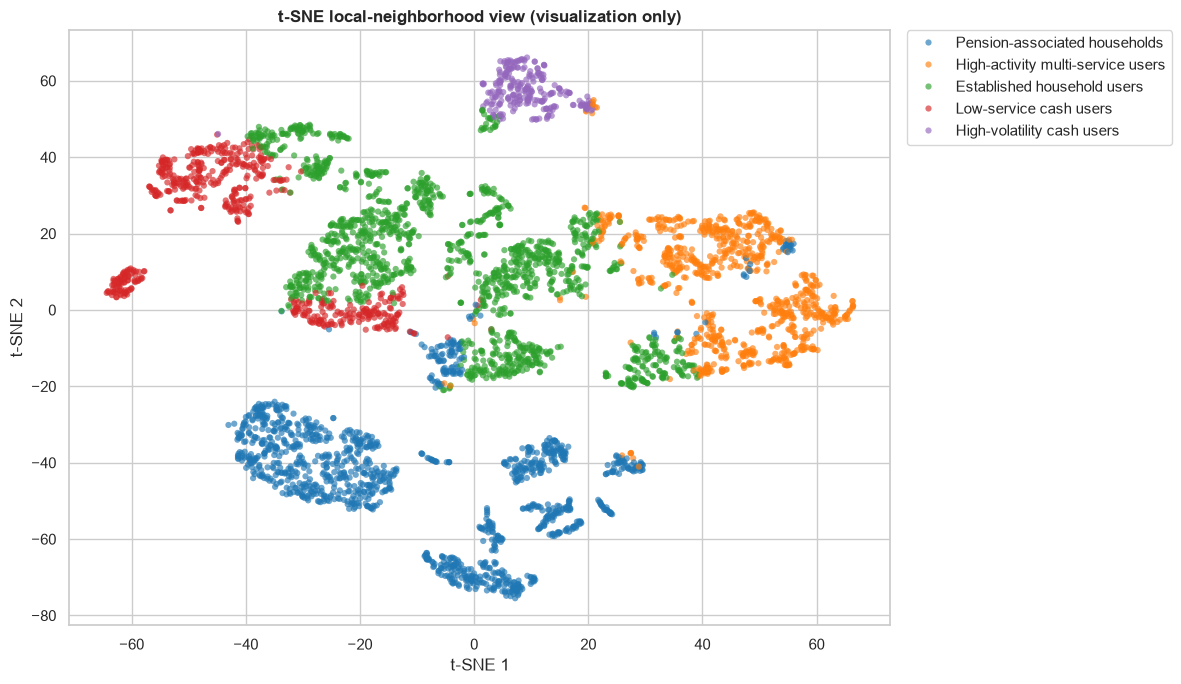

In [16]:
tsne_embedding = TSNE(
    n_components=2,
    perplexity=40,
    init="pca",
    learning_rate="auto",
    max_iter=1_000,
    random_state=RANDOM_STATE,
).fit_transform(transformed_matrix)

tsne_visualization = pd.DataFrame(
    {
        "tSNE1": tsne_embedding[:, 0],
        "tSNE2": tsne_embedding[:, 1],
        "segment_name": segment_names,
    }
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=tsne_visualization,
    x="tSNE1",
    y="tSNE2",
    hue="segment_name",
    palette="tab10",
    s=20,
    alpha=0.65,
    linewidth=0,
    ax=ax,
)
ax.set(title="t-SNE local-neighborhood view (visualization only)", xlabel="t-SNE 1", ylabel="t-SNE 2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
fig.tight_layout()
plt.show()

## 9. Segment interpretation and business relevance

Numerical profiles use medians for continuous/skewed behaviors and account proportions for service indicators. “Defining features” are the three largest absolute K-means centroid coordinates in the transformed standardized space.

In [17]:
profile_data = customer_features.copy()
profile_data["segment_id"] = kmeans_labels
profile_data["segment_name"] = segment_names

continuous_profiles = (
    profile_data.groupby(["segment_id", "segment_name"])[PROFILE_CONTINUOUS_FEATURES]
    .median()
    .add_prefix("median_")
)
service_profiles = (
    profile_data.groupby(["segment_id", "segment_name"])[SERVICE_INDICATORS]
    .mean()
    .add_prefix("rate_")
)
population_profiles = (
    profile_data.groupby(["segment_id", "segment_name"])
    .size()
    .rename("population_size")
    .to_frame()
)
population_profiles["population_share"] = population_profiles["population_size"] / len(profile_data)

feature_display_names = {
    "transactions_per_observed_month": "transaction intensity",
    "average_inflow": "average inflow",
    "inflow_to_outflow_ratio": "inflow/outflow ratio",
    "average_balance": "average balance",
    "negative_balance_share": "negative-balance exposure",
    "cash_deposit_share": "cash-deposit share",
    "cash_withdrawal_share": "cash-withdrawal share",
    "transaction_diversity": "transaction diversity",
    "service_diversity": "service diversity",
}

def defining_feature_text(segment_id: int) -> str:
    centroid = pd.Series(kmeans_model.cluster_centers_[segment_id], index=MODEL_FEATURES)
    strongest = centroid.abs().nlargest(3).index
    descriptions = []
    for feature in strongest:
        direction = "high" if centroid[feature] > 0 else "low"
        descriptions.append(
            f"{direction} {feature_display_names[feature]} ({centroid[feature]:+.2f} SD)"
        )
    return "; ".join(descriptions)


segment_narratives = {
    "Pension-associated households": {
        "transaction_patterns": "Lower-value recurring inflows, very low cash-deposit share, and regular household payments.",
        "balance_characteristics": "Lowest typical balances and comparatively low balance volatility.",
        "banking_service_usage": "Nearly universal standing orders and household payments; pension deposits are common; cards and loans are uncommon.",
        "possible_business_relevance": "Investigate accessible servicing and reliable recurring-payment support.",
        "limitations": "The pension flag is historical and not universal in this segment; it must not be treated as age, vulnerability, or suitability evidence.",
    },
    "Established household users": {
        "transaction_patterns": "Moderate activity with larger inflows and mixed cash usage.",
        "balance_characteristics": "High typical balances with moderate volatility.",
        "banking_service_usage": "Household payments and standing orders are common; cards and leasing appear more often than portfolio average.",
        "possible_business_relevance": "Investigate everyday-service experience and channel support for established relationships.",
        "limitations": "High balance and service use do not establish profitability, loyalty, or unmet product need.",
    },
    "High-activity multi-service users": {
        "transaction_patterns": "Highest transaction intensity and transaction diversity with relatively lower cash-withdrawal share.",
        "balance_characteristics": "High typical balances with moderate volatility.",
        "banking_service_usage": "Broadest service use; loans, cards, insurance, standing orders, and salary-like deposits are comparatively frequent.",
        "possible_business_relevance": "Investigate service coordination and operational capacity for complex account activity.",
        "limitations": "High activity is not evidence of customer value, credit suitability, or willingness to receive additional services.",
    },
    "High-volatility cash users": {
        "transaction_patterns": "High cash-withdrawal share and relatively high outflows.",
        "balance_characteristics": "Highest balance volatility and the clearest negative-balance exposure.",
        "banking_service_usage": "Fewer recurring services, although loans and leasing are present for some accounts.",
        "possible_business_relevance": "Investigate aggregate cash-flow support and servicing friction without punitive treatment.",
        "limitations": "Volatility and negative balances are valid financial behavior, not proof of distress, default, fraud, or misconduct.",
    },
    "Low-service cash users": {
        "transaction_patterns": "Lower activity and diversity with a high cash-deposit share.",
        "balance_characteristics": "Mid-range typical balances and moderate volatility.",
        "banking_service_usage": "Few observed services; loans, salary-like deposits, insurance, and leasing are rare.",
        "possible_business_relevance": "Investigate voluntary onboarding, education, or simpler channel support.",
        "limitations": "Low observed service use does not imply low engagement, unmet need, digital exclusion, or receptiveness to marketing.",
    },
}

segment_profiles = population_profiles.join(continuous_profiles).join(service_profiles).reset_index()
segment_profiles["defining_features"] = segment_profiles["segment_id"].map(defining_feature_text)
for narrative_column in [
    "transaction_patterns",
    "balance_characteristics",
    "banking_service_usage",
    "possible_business_relevance",
    "limitations",
]:
    segment_profiles[narrative_column] = segment_profiles["segment_name"].map(
        lambda segment_name: segment_narratives[segment_name][narrative_column]
    )

display(
    segment_profiles[
        [
            "segment_name",
            "population_size",
            "population_share",
            "defining_features",
            "median_transactions_per_observed_month",
            "median_average_inflow",
            "median_average_balance",
            "median_balance_std",
            "median_service_diversity",
        ]
    ]
)

,segment_name,population_size,population_share,defining_features,median_transactions_per_observed_month,median_average_inflow,median_average_balance,median_balance_std,median_service_diversity
0,Pension-associated households,1305,0.290000,low average inflow (-1.09 SD); low cash-deposi...,4.900000,2542.140625,20899.565217,5000.970702,3.0
1,Established household users,1519,0.337556,high average inflow (+0.71 SD); high average b...,5.538462,10793.585859,45623.111111,14253.370040,2.0
2,High-activity multi-service users,838,0.186222,high transaction intensity (+1.31 SD); high tr...,7.291078,11062.640341,45009.918542,14011.153640,4.0
3,High-volatility cash users,251,0.055778,high negative-balance exposure (+3.96 SD); hig...,5.500000,10677.592000,35546.471698,25030.567393,1.0
4,Low-service cash users,587,0.130444,low transaction diversity (-1.39 SD); high cas...,4.638298,3247.747475,30737.750000,10477.222205,0.0


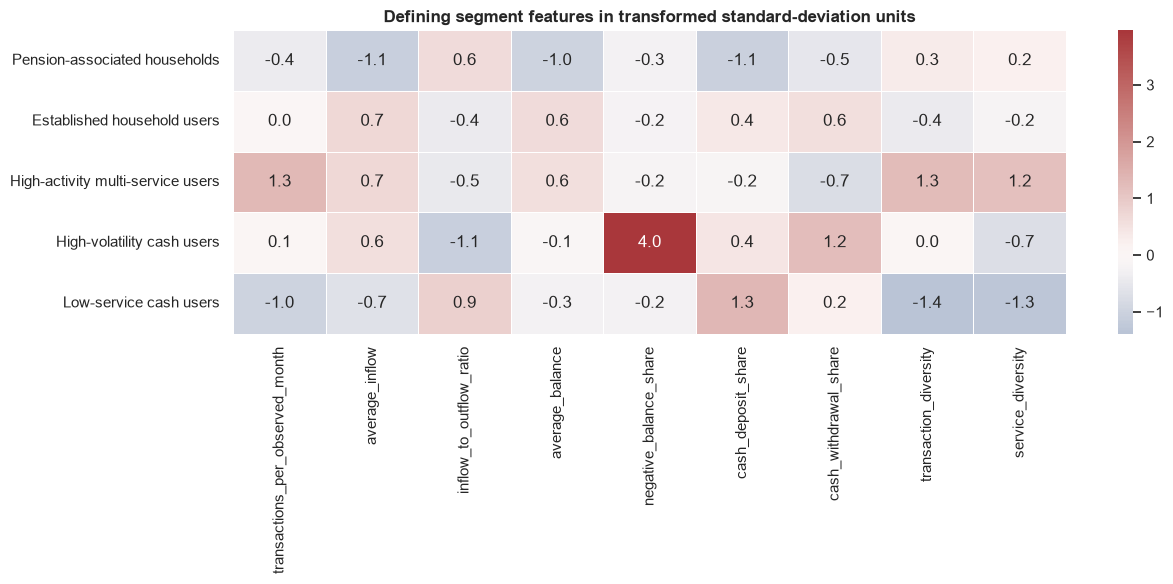

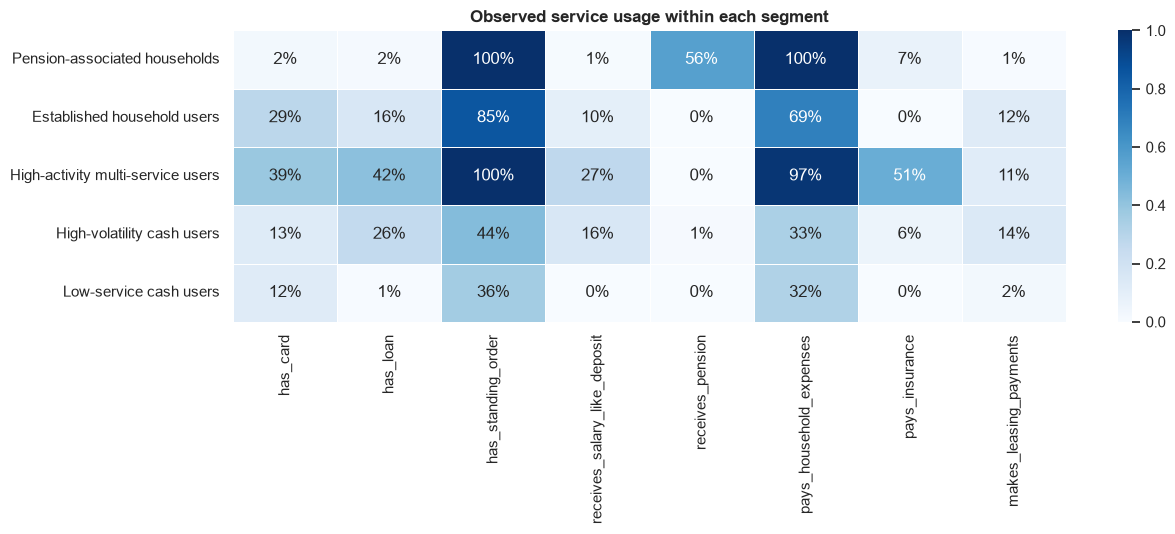

In [18]:
centroid_profile = pd.DataFrame(
    kmeans_model.cluster_centers_,
    index=[SEGMENT_NAME_MAP[index] for index in range(SELECTED_K)],
    columns=MODEL_FEATURES,
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    centroid_profile,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".1f",
    linewidths=0.4,
    ax=ax,
)
ax.set(title="Defining segment features in transformed standard-deviation units", xlabel="", ylabel="")
fig.tight_layout()
plt.show()

service_rate_profile = segment_profiles.set_index("segment_name")[
    ["rate_" + feature for feature in SERVICE_INDICATORS]
]
service_rate_profile.columns = [column.removeprefix("rate_") for column in service_rate_profile.columns]

fig, ax = plt.subplots(figsize=(13, 5.5))
sns.heatmap(
    service_rate_profile,
    cmap="Blues",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".0%",
    linewidths=0.4,
    ax=ax,
)
ax.set(title="Observed service usage within each segment", xlabel="", ylabel="")
fig.tight_layout()
plt.show()

In [19]:
segment_story = segment_profiles[
    [
        "segment_name",
        "population_size",
        "transaction_patterns",
        "balance_characteristics",
        "banking_service_usage",
        "possible_business_relevance",
        "limitations",
    ]
]
display(segment_story)

,segment_name,population_size,transaction_patterns,balance_characteristics,banking_service_usage,possible_business_relevance,limitations
0,Pension-associated households,1305,"Lower-value recurring inflows, very low cash-d...",Lowest typical balances and comparatively low ...,Nearly universal standing orders and household...,Investigate accessible servicing and reliable ...,The pension flag is historical and not univers...
1,Established household users,1519,Moderate activity with larger inflows and mixe...,High typical balances with moderate volatility.,Household payments and standing orders are com...,Investigate everyday-service experience and ch...,High balance and service use do not establish ...
2,High-activity multi-service users,838,Highest transaction intensity and transaction ...,High typical balances with moderate volatility.,"Broadest service use; loans, cards, insurance,...",Investigate service coordination and operation...,High activity is not evidence of customer valu...
3,High-volatility cash users,251,High cash-withdrawal share and relatively high...,Highest balance volatility and the clearest ne...,"Fewer recurring services, although loans and l...",Investigate aggregate cash-flow support and se...,Volatility and negative balances are valid fin...
4,Low-service cash users,587,Lower activity and diversity with a high cash-...,Mid-range typical balances and moderate volati...,"Few observed services; loans, salary-like depo...","Investigate voluntary onboarding, education, o...",Low observed service use does not imply low en...


## 10. Behavioral outliers after segmentation

An outlier is an account that differs from a defined behavioral reference—not evidence of fraud, harm, or error. Four complementary signals are calculated:

1. **Centroid distance:** distance from the assigned K-means centre, ranked within segment.
2. **Low GMM membership:** low maximum probability under the matched five-component GMM.
3. **Robust within-segment deviation:** largest median/MAD-based deviation across transformed model features, with IQR or standard-deviation fallback when MAD is zero.
4. **Isolation Forest:** model-independent nonlinear comparison using a 1% contamination setting.

An account is selected for case-study review only when at least two signals flag it. This consensus rule reduces dependence on any single geometric assumption.

In [20]:
centroid_distances = np.linalg.norm(
    transformed_matrix - kmeans_model.cluster_centers_[kmeans_labels],
    axis=1,
)
centroid_distance_percentiles = (
    pd.Series(centroid_distances)
    .groupby(kmeans_labels)
    .rank(pct=True)
    .to_numpy()
)

gmm_max_membership_probability = gmm_membership_probabilities.max(axis=1)

robust_deviation_matrix = np.zeros_like(transformed_matrix)
for segment_id in range(SELECTED_K):
    segment_mask = kmeans_labels == segment_id
    segment_values = transformed_matrix[segment_mask]
    segment_median = np.median(segment_values, axis=0)
    mad_scale = 1.4826 * np.median(np.abs(segment_values - segment_median), axis=0)
    first_quartile, third_quartile = np.quantile(segment_values, [0.25, 0.75], axis=0)
    iqr_scale = (third_quartile - first_quartile) / 1.349
    standard_deviation_scale = segment_values.std(axis=0)
    robust_scale = np.where(
        mad_scale > 1e-8,
        mad_scale,
        np.where(iqr_scale > 1e-8, iqr_scale, standard_deviation_scale),
    )
    robust_scale = np.where(robust_scale > 1e-8, robust_scale, 1.0)
    robust_deviation_matrix[segment_mask] = np.abs(
        (segment_values - segment_median) / robust_scale
    )

robust_deviation_score = robust_deviation_matrix.max(axis=1)
top_robust_feature = np.asarray(MODEL_FEATURES)[robust_deviation_matrix.argmax(axis=1)]

isolation_forest = IsolationForest(
    n_estimators=300,
    contamination=0.01,
    random_state=RANDOM_STATE,
).fit(transformed_matrix)
isolation_anomaly_score = -isolation_forest.score_samples(transformed_matrix)
isolation_flag = isolation_forest.predict(transformed_matrix) == -1

In [21]:
behavioral_outliers = pd.DataFrame(
    {
        "account_id": customer_features["account_id"],
        "segment_id": kmeans_labels,
        "segment_name": segment_names,
        "centroid_distance": centroid_distances,
        "centroid_distance_percentile_within_segment": centroid_distance_percentiles,
        "gmm_max_membership_probability": gmm_max_membership_probability,
        "robust_deviation_score": robust_deviation_score,
        "top_robust_deviation_feature": top_robust_feature,
        "isolation_anomaly_score": isolation_anomaly_score,
    }
)

behavioral_outliers["centroid_distance_flag"] = (
    behavioral_outliers["centroid_distance_percentile_within_segment"] >= 0.99
)
behavioral_outliers["low_gmm_membership_flag"] = (
    behavioral_outliers["gmm_max_membership_probability"]
    <= behavioral_outliers["gmm_max_membership_probability"].quantile(0.01)
)
behavioral_outliers["robust_deviation_flag"] = (
    behavioral_outliers["robust_deviation_score"]
    >= behavioral_outliers["robust_deviation_score"].quantile(0.99)
)
behavioral_outliers["isolation_forest_flag"] = isolation_flag

flag_columns = [
    "centroid_distance_flag",
    "low_gmm_membership_flag",
    "robust_deviation_flag",
    "isolation_forest_flag",
]
behavioral_outliers["outlier_signal_count"] = behavioral_outliers[flag_columns].sum(axis=1)
behavioral_outliers["is_behavioral_outlier"] = behavioral_outliers["outlier_signal_count"] >= 2

behavioral_outliers["composite_outlier_percentile"] = (
    behavioral_outliers["centroid_distance_percentile_within_segment"]
    + behavioral_outliers["robust_deviation_score"].rank(pct=True)
    + (1 - behavioral_outliers["gmm_max_membership_probability"]).rank(pct=True)
    + behavioral_outliers["isolation_anomaly_score"].rank(pct=True)
) / 4

segment_feature_medians = profile_data.groupby("segment_id")[MODEL_FEATURES].median()
top_feature_values = []
top_feature_segment_medians = []
for row_number, outlier_row in behavioral_outliers.iterrows():
    feature_name = outlier_row["top_robust_deviation_feature"]
    segment_id = int(outlier_row["segment_id"])
    top_feature_values.append(customer_features.loc[row_number, feature_name])
    top_feature_segment_medians.append(segment_feature_medians.loc[segment_id, feature_name])

behavioral_outliers["top_robust_feature_value"] = top_feature_values
behavioral_outliers["top_robust_feature_segment_median"] = top_feature_segment_medians

outlier_summary = pd.Series(
    {
        "accounts": len(behavioral_outliers),
        "centroid-distance flags": behavioral_outliers["centroid_distance_flag"].sum(),
        "low-GMM-membership flags": behavioral_outliers["low_gmm_membership_flag"].sum(),
        "robust-deviation flags": behavioral_outliers["robust_deviation_flag"].sum(),
        "Isolation Forest flags": behavioral_outliers["isolation_forest_flag"].sum(),
        "consensus behavioral outliers": behavioral_outliers["is_behavioral_outlier"].sum(),
    },
    name="value",
)
display(outlier_summary.to_frame())

,value
accounts,4500
centroid-distance flags,48
low-GMM-membership flags,45
robust-deviation flags,45
Isolation Forest flags,45
consensus behavioral outliers,16


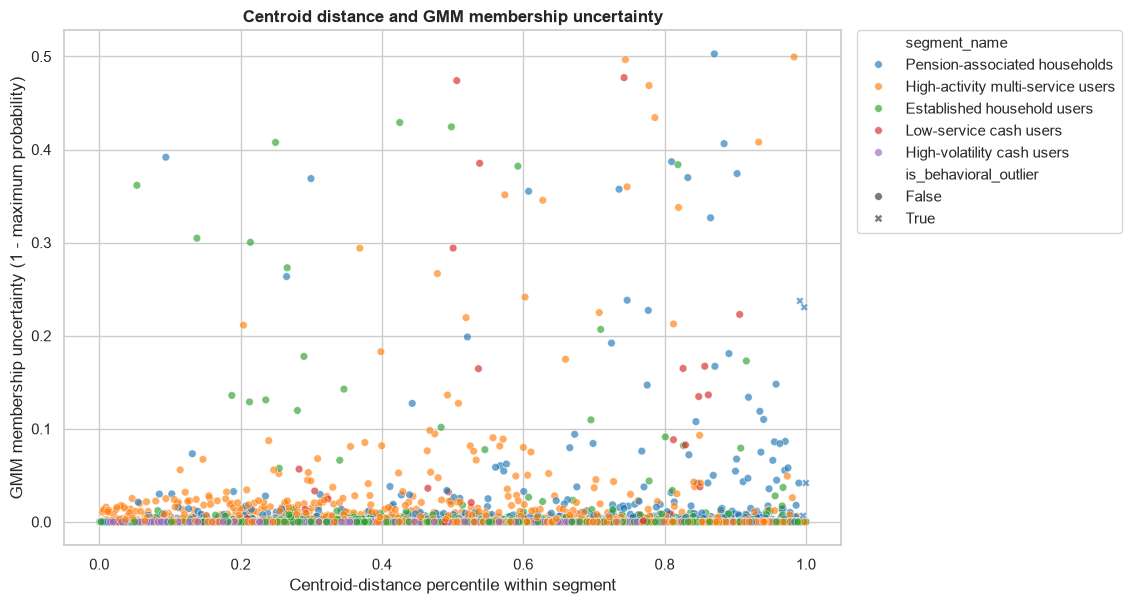

,account_id,segment_name,outlier_signal_count,top_robust_deviation_feature,top_robust_feature_value,top_robust_feature_segment_median,centroid_distance_percentile_within_segment,gmm_max_membership_probability,composite_outlier_percentile
0,3324,Pension-associated households,3,cash_deposit_share,0.365079,0.008475,0.997701,0.769421,0.957759
1,3276,Pension-associated households,2,cash_deposit_share,0.368421,0.008475,1.000000,0.958282,0.967056
2,696,Pension-associated households,2,transaction_diversity,8.000000,6.000000,0.991571,0.762623,0.945865
3,9227,Pension-associated households,2,cash_deposit_share,0.333333,0.008475,0.996169,0.993374,0.941487
4,4059,High-volatility cash users,2,inflow_to_outflow_ratio,0.795939,1.028392,1.000000,1.000000,0.751722
5,1888,High-activity multi-service users,2,negative_balance_share,0.052209,0.000000,1.000000,1.000000,0.748500
6,5442,High-activity multi-service users,2,negative_balance_share,0.073585,0.000000,0.998807,1.000000,0.745979
7,2335,High-volatility cash users,2,cash_withdrawal_share,0.400749,0.676190,0.996016,1.000000,0.740226


In [22]:
fig, ax = plt.subplots(figsize=(11.5, 6.2))
sns.scatterplot(
    data=behavioral_outliers,
    x="centroid_distance_percentile_within_segment",
    y=1 - behavioral_outliers["gmm_max_membership_probability"],
    hue="segment_name",
    style="is_behavioral_outlier",
    palette="tab10",
    alpha=0.65,
    s=30,
    ax=ax,
)
ax.set(
    title="Centroid distance and GMM membership uncertainty",
    xlabel="Centroid-distance percentile within segment",
    ylabel="GMM membership uncertainty (1 - maximum probability)",
)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
fig.tight_layout()
plt.show()

case_studies = (
    behavioral_outliers.loc[behavioral_outliers["is_behavioral_outlier"]]
    .sort_values(["outlier_signal_count", "composite_outlier_percentile"], ascending=False)
    .head(8)
    .merge(
        customer_features[
            [
                "account_id",
                "transactions_per_observed_month",
                "average_inflow",
                "average_outflow",
                "average_balance",
                "balance_std",
                "negative_balance_share",
                "cash_deposit_share",
                "cash_withdrawal_share",
                "transaction_diversity",
                "service_diversity",
            ]
        ],
        on="account_id",
        validate="one_to_one",
    )
)
display(
    case_studies[
        [
            "account_id",
            "segment_name",
            "outlier_signal_count",
            "top_robust_deviation_feature",
            "top_robust_feature_value",
            "top_robust_feature_segment_median",
            "centroid_distance_percentile_within_segment",
            "gmm_max_membership_probability",
            "composite_outlier_percentile",
        ]
    ]
)

The case-study table identifies *why* an account is unusual relative to its segment and shows the corresponding segment median. It does not establish an explanation. Investigation would require contemporaneous context, data-quality review, and appropriate authority; no account should receive adverse treatment from this analysis.

## 11. Persist and validate outputs

| Artifact | Grain or type | Purpose |
|---|---|---|
| `customer_segments.parquet` | One row per account | Selected segment assignment and PCA coordinates |
| `segment_profiles.parquet` | One row per segment | Numeric profiles, interpretation, relevance, and limitations |
| `behavioral_outliers.parquet` | One row per account | Transparent outlier scores, flags, and consensus selection |
| `preprocessing_pipeline.joblib` | Fitted transformer | Reproduce Yeo-Johnson transformation and scaling |
| `pca.joblib` | Fitted PCA | Reproduce components, loadings, and coordinates |
| `clustering_model.joblib` | Fitted K-means | Reproduce primary segment assignments |

In [23]:
customer_segments = pd.DataFrame(
    {
        "account_id": customer_features["account_id"],
        "segment_id": kmeans_labels,
        "segment_name": segment_names,
        "clustering_algorithm": "K-means",
        "number_of_segments": SELECTED_K,
        "pca_component_1": pca_scores[:, 0],
        "pca_component_2": pca_scores[:, 1],
    }
).sort_values("account_id").reset_index(drop=True)

behavioral_outliers = behavioral_outliers.sort_values("account_id").reset_index(drop=True)
segment_profiles = segment_profiles.sort_values("segment_id").reset_index(drop=True)

table_outputs = {
    "customer_segments.parquet": customer_segments,
    "segment_profiles.parquet": segment_profiles,
    "behavioral_outliers.parquet": behavioral_outliers,
}

for index, (filename, frame) in enumerate(table_outputs.items()):
    relation_name = f"segmentation_output_{index}"
    output_path = PROCESSED_DIR / filename
    connection.register(relation_name, frame)
    connection.execute(
        "COPY (SELECT * FROM "
        + relation_name
        + ") TO "
        + sql_literal(output_path)
        + " (FORMAT PARQUET, COMPRESSION ZSTD)"
    )
    connection.unregister(relation_name)

model_outputs = {
    "preprocessing_pipeline.joblib": preprocessing_pipeline,
    "pca.joblib": pca,
    "clustering_model.joblib": kmeans_model,
}
for filename, model in model_outputs.items():
    joblib.dump(model, MODELS_DIR / filename)

In [24]:
output_validation_rows = []
for filename, frame in table_outputs.items():
    output_path = PROCESSED_DIR / filename
    stored_rows = connection.execute(
        "SELECT COUNT(*) FROM read_parquet(" + sql_literal(output_path) + ")"
    ).fetchone()[0]
    output_validation_rows.append(
        {
            "artifact": filename,
            "path": str(output_path.relative_to(PROJECT_ROOT)),
            "expected_rows": len(frame),
            "stored_rows": stored_rows,
            "columns": len(frame.columns),
            "size_kb": round(output_path.stat().st_size / 1024, 1),
            "valid": stored_rows == len(frame),
        }
    )

loaded_preprocessor = joblib.load(MODELS_DIR / "preprocessing_pipeline.joblib")
loaded_pca = joblib.load(MODELS_DIR / "pca.joblib")
loaded_clustering_model = joblib.load(MODELS_DIR / "clustering_model.joblib")

validation_sample = customer_features[MODEL_FEATURES].head(10)
sample_transformed = loaded_preprocessor.transform(validation_sample)
sample_pca = loaded_pca.transform(sample_transformed)
sample_segments = loaded_clustering_model.predict(sample_transformed)

for filename in model_outputs:
    output_path = MODELS_DIR / filename
    output_validation_rows.append(
        {
            "artifact": filename,
            "path": str(output_path.relative_to(PROJECT_ROOT)),
            "expected_rows": None,
            "stored_rows": None,
            "columns": None,
            "size_kb": round(output_path.stat().st_size / 1024, 1),
            "valid": output_path.is_file(),
        }
    )

output_validation = pd.DataFrame(output_validation_rows)
display(output_validation)

assert output_validation["valid"].all()
assert len(customer_segments) == customer_segments["account_id"].nunique() == 4_500
assert len(segment_profiles) == SELECTED_K
assert len(behavioral_outliers) == behavioral_outliers["account_id"].nunique() == 4_500
assert sample_transformed.shape == (10, len(MODEL_FEATURES))
assert sample_pca.shape == (10, len(MODEL_FEATURES))
assert len(sample_segments) == 10

,artifact,path,expected_rows,stored_rows,columns,size_kb,valid
0,customer_segments.parquet,data/processed/customer_segments.parquet,4500.0,4500.0,7.0,80.5,True
1,segment_profiles.parquet,data/processed/segment_profiles.parquet,5.0,5.0,30.0,8.9,True
2,behavioral_outliers.parquet,data/processed/behavioral_outliers.parquet,4500.0,4500.0,18.0,221.5,True
3,preprocessing_pipeline.joblib,models/preprocessing_pipeline.joblib,NaN,NaN,NaN,1.5,True
4,pca.joblib,models/pca.joblib,NaN,NaN,NaN,1.8,True
5,clustering_model.joblib,models/clustering_model.joblib,NaN,NaN,NaN,18.6,True


## 12. Findings and handoff

- Nine selected behaviors are transformed and scaled reproducibly; omitting skewness treatment produces an unstable tiny cluster.
- The first two PCs explain about 63.4% of variance, while four PCs explain about 86.2%. PCA loadings support interpretable activity/breadth and financial-scale dimensions.
- K-means with five segments provides the strongest tested combination of elbow behavior, silhouette, Davies-Bouldin score, cluster size, stability, and business interpretability.
- The five segments contain 1,305 pension-associated households, 1,519 established household users, 838 high-activity multi-service users, 251 high-volatility cash users, and 587 low-service cash users.
- GMM is stable but less separated at matched K. Its membership probabilities remain useful as a complementary uncertainty signal.
- Sixteen accounts meet the conservative two-signal behavioral-outlier rule. They are analytical case studies, not suspicious accounts or fraud cases.
- Segment names summarize dominant historical patterns and must not become permanent customer labels.

**Next notebook:** `04_validation_and_insights.ipynb` will validate segment usefulness and limitations, conduct the bounded supervised-learning case study, examine data-centric error patterns, and synthesize the final recommendations.